# Multi-Objective Evolutionary Merging for L2S Reasoning

Run these commands to install all the necessary libraries and packages

%cd mergenetic \
!pip install -r requirements.txt \
!pip install -e . 

%cd Qwen2.5-Math/evaluation \
!pip install -r requirements.txt \
%cd latex2sympy \
!pip install -e . 

In [1]:
# ==== Imports ====
import os, random, numpy as np, torch

# pymoo components
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

# lm_eval
from lm_eval.tasks import TaskManager

# Hugging Face 
from huggingface_hub import whoami
from huggingface_hub import notebook_login
from huggingface_hub import snapshot_download

# Mergekit and Mergenetic
import mergenetic
from mergenetic.merging.taskarithmetic_merger import TaskArithmeticMerger
from mergenetic.merging.ties_merger import TiesMerger
from mergenetic.searcher import Searcher
from mergenetic.utils import ConfigLmEval
from mergenetic.optimization.predefined_problems import L2SMathReasoningProblem, ConfigQwen
from mergenetic import PROJECT_ROOT

INFO 03-13 20:27:15 [__init__.py:239] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 03-13 20:27:17 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


PROJECT_ROOT IS HARCODED AT /leonardo/home/userexternal/miacobel


In [2]:
import sys, importlib, pathlib

# 0) make sure the real code exists
real_pkg_dir = pathlib.Path(f"{PROJECT_ROOT}/project_new/mergenetic/src/mergenetic")
if not real_pkg_dir.exists():
    raise RuntimeError("mergenetic/src/mergenetic not found – is the repo cloned?")

# 1) purge every cached mergenetic module
for name in list(sys.modules):
    if name == "mergenetic" or name.startswith("mergenetic."):
        del sys.modules[name]

# 2) put src/ directory *first* on sys.path
src_root = str(real_pkg_dir.parent)  # /mergenetic/src
if src_root not in sys.path:
    sys.path.insert(0, src_root)

# 3) also remove /content from sys.path if present
for bad in ("", "/content"):
    if bad in sys.path:
        sys.path.remove(bad)

# 4) reload
importlib.invalidate_caches()
import mergenetic, inspect, textwrap

print("Now using:", inspect.getfile(mergenetic))
print("Public names:", textwrap.shorten(", ".join(dir(mergenetic)), 100))

PROJECT_ROOT IS HARCODED AT /leonardo/home/userexternal/miacobel


Now using: /leonardo/home/userexternal/miacobel/project_new/mergenetic/src/mergenetic/__init__.py
Public names: Any, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, CACHE_DIR, Config, ConfigLmEval, [...]


## Download Models form HF Hub

Before we begin, we'll need access to the `HuggingFace Hub` using an authentication token.

If you haven’t done this before, follow these steps:

1. Create a **read access token** here:  
   👉 [https://huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)

2. Use the token in your code or environment to authenticate:

In [ ]:
notebook_login()

try:
    user_info = whoami()
    print("✅ Logged in as:", user_info["name"])
except Exception as e:
    print("❌ Not logged in:", str(e))

In [ ]:
# Directory where to store models before running Evo Merging on Cineca 
model_dir = "/leonardo_scratch/fast/IscrC_LENS/miacobel/model"
os.makedirs(model_dir, exist_ok=True)

# DEEPSEEK-R1 (System 2)
# -- deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
# -- deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
# -- deepseek-ai/DeepSeek-R1-Distill-Qwen-14B
deepseek_repo = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
snapshot_download(
    repo_id=deepseek_repo,
    local_dir=os.path.join(model_dir, "DeepSeek-R1-Distill-Qwen-7B")
)

# QWEN (System 1)
# -- Qwen/Qwen2.5-Math-1.5B
# -- Qwen/Qwen2.5-Math-7B
# -- Qwen/Qwen2.5-14B
qwen_math_repo = "Qwen/Qwen2.5-Math-7B"
snapshot_download(
    repo_id=qwen_math_repo,
    local_dir=os.path.join(model_dir, "Qwen2.5-Math-7B")
)


# WORKFLOW

### EVOLUTIONARY SEARCH
To launch the evolutionary search:

1) Download a pair of models:
- DeepSeek-R1-Distill-Qwen-1.5B + Qwen2.5-Math-1.5B
- DeepSeek-R1-Distill-Qwen-7B + Qwen2.5-Math-7B 
- DeepSeek-R1-Distill-Qwen-14B + Qwen2.5-14B

2) Go to `mergenetic/scripts` and modify the Python file `Mergenetic-TA.py` or `Mergenetic-TIES.py` as needed to specify model paths, the merger (GA for single-objective or NSGA2 for multi-objective optimization), the dataset to use for evolutionary search (name, split, and number of samples), population size, number of iterations, etc. 

After the evolutionary search terminates, you will find in `mergenetic/experiments/evolutionary-merging-qwen` a folder named after the `run_id`, containing, among other files, a `mergekit.yaml` file and a `_solutions.csv` file with the Pareto-optimal solutions found during the evolutionary search, with:

- objective_0 = -accuracy
- objective_1 = length (number of tokens)
- genotype_0 = weight 
- genotype_1 = density (only for TIES merging)

Use these genotypes to fill the `config.yaml` file, and then materialize these solutions by running the script:

`/mergenetic/scripts/run_mergekit.sh`

---

### EVALUATION

The slow-thinking model (DeepSeek-R1-Distill-Qwen) and all merged models are evaluated as follows:

- template prompt `deepseek-math`, containing User/Assistant roles and the instruction  
  "Please reason step by step and put your final answer within \boxed{}";
- zero-shot mode;
- maximum sequence length of 10240 tokens;
- seed 0 for reproducibility.

The fast-thinking model (Qwen2.5-Math or Qwen2.5) is evaluated as follows:

- template prompt `cot`;
- few-shot mode (with 5 examples);
- maximum sequence length of 8192 tokens;
- seed 0 for reproducibility.

To evaluate the models, use the **Qwen2.5-Math** library and run:

`Qwen2.5-Math/evaluation/scripts/l2s_eval.sh`

In this script you can specify the model path, prompt template, maximum sequence length, benchmarks, few-shot or zero-shot mode, etc.

Finally, you can read per-benchmark and overall performance metrics (unnormalized and normalized accuracy and length) by running:

`Qwen2.5-Math/evaluation/scripts/extract_result.py`

Pass as arguments the path of the folder containing the benchmark subdirectories and the tokenizer path (you can use the DeepSeek-R1-Distill-Qwen tokenizer, since merged models inherit its tokenizer).

In [11]:
import matplotlib.pyplot as plt
import numpy as np

family_colors = {
    "DeepSeek-R1-Distill-Qwen": "#3C56D9",
    "Qwen2.5": "#644FD7",
    "Qwen2.5-Math": "#644FD7",
    "Average Merging": "#8cd5bd",
    "Task Arithmetic": "#09979a",
    "TIES Merging": "#05564a",
    "ACM-Average": "#ebc400f6",
    "ACM-TA": "#ee9b00",
    "ACM-TIES": "#d06800",
    "Mergenetic-TA (accuracy)": "#cb2813",
    "Mergenetic-TA (length)": "#840606",
    "Mergenetic-TA (Random)": "#669bbc",
    "Mergenetic-TA (Entropy)": "#1B4578",
}

markers = {
    "DeepSeek-R1-Distill-Qwen": "D",
    "Qwen2.5": "D",
    "Qwen2.5-Math": "D",
    "ACM-Average": "s",
    "ACM-TA": "s",
    "ACM-TIES": "s",
    "Average Merging": "o",
    "Task Arithmetic": "o",
    "TIES Merging": "o",
    "Mergenetic-TA (Random)": "o",
    "Mergenetic-TA (Entropy)": "o",
    "Mergenetic-TA (accuracy)": "^",
    "Mergenetic-TA (length)": "v",
}

def pareto_front(points):
    """
    points: lista di tuple (accuracy, length)
    ritorna i punti Pareto ordinati per length crescente
    """
    pareto = []
    for i, (a1, l1) in enumerate(points):
        dominated = False
        for j, (a2, l2) in enumerate(points):
            if j == i:
                continue
            if (a2 >= a1 and l2 <= l1) and (a2 > a1 or l2 < l1):
                dominated = True
                break
        if not dominated:
            pareto.append((a1, l1))
    pareto.sort(key=lambda x: x[1])
    return pareto


def plot(avg_models, weighted_models, model_label, save_path=None):
    
    def plot_panel(ax, data, title, ylabel):

        deepseek_acc, deepseek_len, _ = data["DeepSeek-R1-Distill-Qwen"]
        family_points = {}
        pareto_points = {}

        for _, (accuracy, length, family) in data.items():
            compression = 100 * (1 - length / deepseek_len)

            family_points.setdefault(family, []).append(
                (compression, accuracy)
            )
            pareto_points.setdefault(family, []).append(
                (accuracy, length)
            )
        all_acc = [a for (a, _, _) in data.values()]
        ymin = max(0, min(all_acc) - 2)
        ymax = min(100, max(all_acc) + 2)

        printed = set()
        
        for fam, color in family_colors.items():
            pts = family_points.get(fam, [])
            if not pts:
                continue
            xs, ys = zip(*pts)
            label = fam if fam not in printed else None
            printed.add(fam)

            ax.scatter(
                xs,
                ys,
                color=color,
                marker=markers.get(fam, "o"),
                s=100,
                edgecolor="black",
                linewidth=0.5,
                alpha=0.9,
                label=label,
            )

            if fam in ["Mergenetic-TA (Random)", "Mergenetic-TA (Entropy)"]:
                pf = pareto_front(pareto_points[fam])
                px = [100 * (1 - l / deepseek_len) for (_, l) in pf]
                py = [a for (a, _) in pf]
                linestyle = "--" if fam == "Mergenetic-TA (Random)" else "-"
                
                ax.plot(
                    px,
                    py,
                    color=color,
                    linestyle=linestyle,
                    linewidth=1.5,
                    alpha=0.9,
                )
        ax.axhline(
            y=deepseek_acc,
            color="black",
            linestyle="--",
            linewidth=0.9,
            alpha=0.5,
        )
        ax.set_xlim(-5, 90)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, linestyle="--", alpha=0.3)

        ax.set_xlabel("Length Reduction vs R1 (%)", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_title(title, fontsize=18)

    plt.style.use("seaborn-v0_8-whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=400)

    plot_panel(
        axes[0],
        avg_models,
        "Average Accuracy vs Length Reduction",
        "Average Accuracy (%)",
    )

    plot_panel(
        axes[1],
        weighted_models,
        "Weighted Accuracy vs Length Reduction",
        "Weighted Accuracy (%)",
    )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Merging Method " + model_label,
        fontsize=12,
        title_fontsize=14,
        ncol=6,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
    )

    if save_path:
        plt.savefig(save_path, dpi=700, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    
def percentage_length_reduction(deepseek_len, merged_len):
    riduzione = ((deepseek_len - merged_len) / deepseek_len) * 100
    return riduzione

## PLOTS

In [1]:
!python /leonardo/home/userexternal/miacobel/project_new/Qwen2.5-Math/evaluation/scripts/extract_result.py \
    --root_folder /leonardo/home/userexternal/miacobel/project_new/Qwen2.5-Math/evaluation/outputs/Mergenetic/TA/1.5B/Entropy/01 \
    --model_name_or_path deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B # tokenizer path (use DeepSeek-R1-Distill-Qwen)

Benchmark            Samples    Accuracy   Length    
------------------------------------------------------------
aime24               30         3.3        3341.5    
college_math         2818       46.8       822.2     
gsm8k                1319       81.5       408.7     
math500              500        70.8       1225.1    
minerva_math         272        30.1       1044.2    
olympiadbench        675        34.8       2038.5    
------------------------------------------------------------
Average              -          44.5       1480.0    
Weighted Average     -          54.6       931.4     


In [36]:
avg_riduzione = percentage_length_reduction(3706.2, 1480.0)
print(f"Riduzione percentuale (average): {avg_riduzione:.2f}\%")

weighted_riduzione = percentage_length_reduction(2158.6, 931.4)
print(f"Riduzione percentuale (weighted): {weighted_riduzione:.2f}\%")

Riduzione percentuale (average): 60.07\%
Riduzione percentuale (weighted): 56.85\%


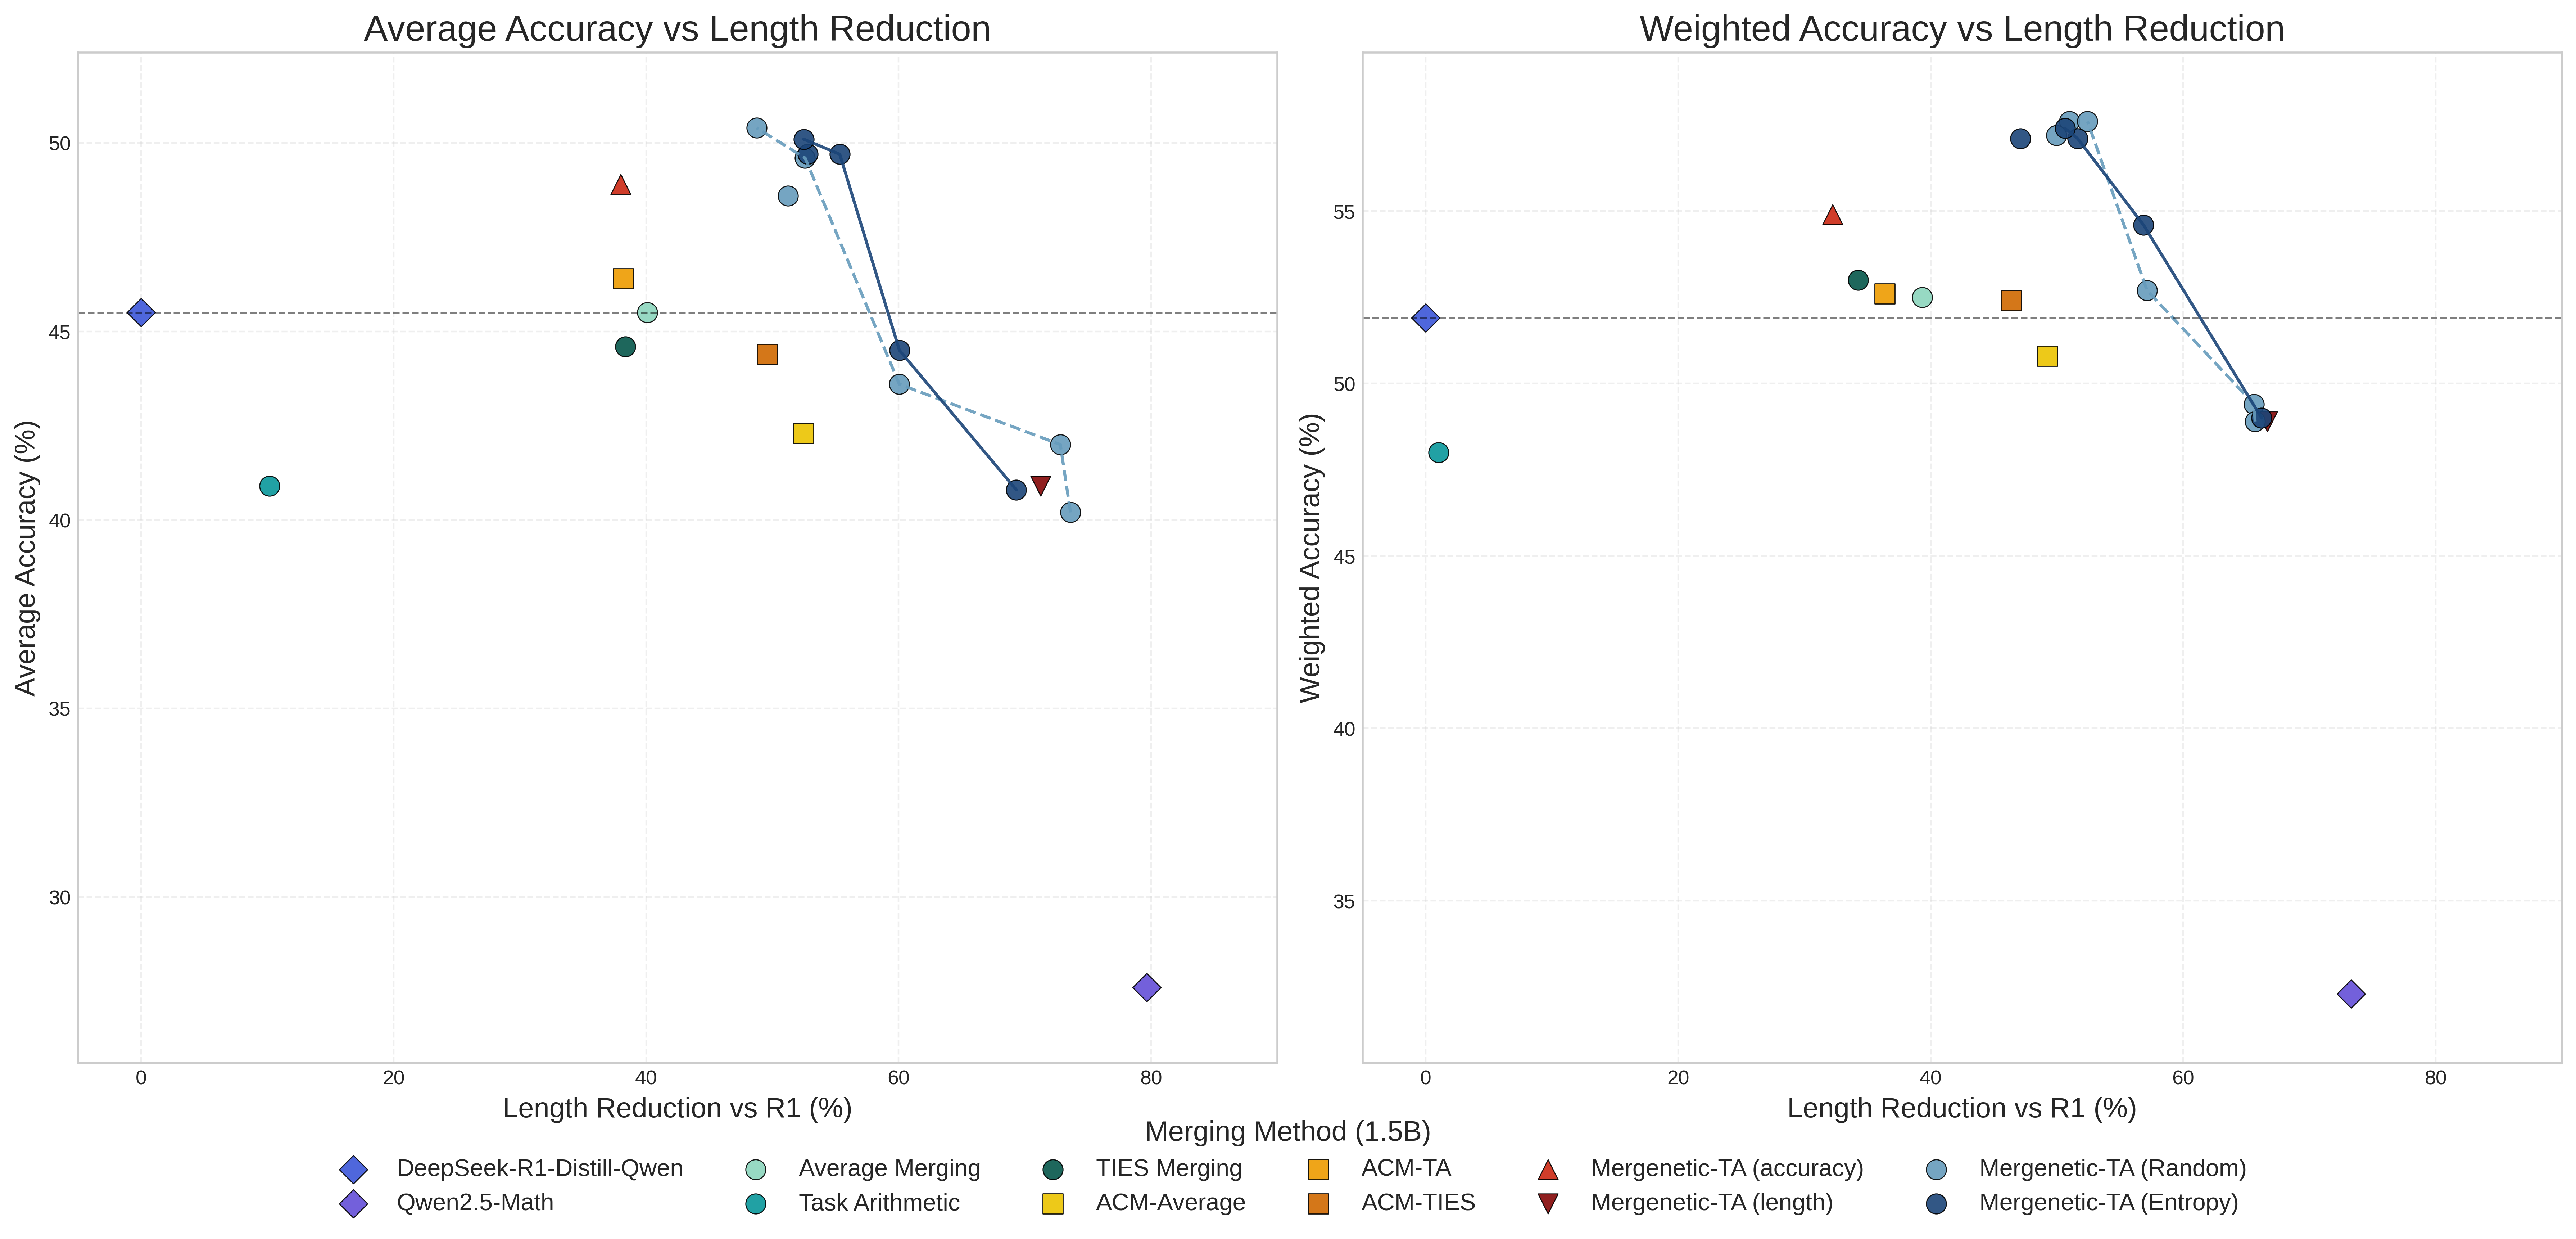

In [17]:
# === 1.5B Data (Avg e Weighted) ===
avg_models_1dot5B = {
    "DeepSeek-R1-Distill-Qwen": (45.5, 3706.2, "DeepSeek-R1-Distill-Qwen"), 
    "Qwen2.5-Math": (27.6, 753.5, "Qwen2.5-Math"), 
    
    "Average Merging": (45.5, 2219.6, "Average Merging"), 
    "Task Arithmetic": (40.9, 3329.0, "Task Arithmetic"), 
    "TIES Merging": (44.6, 2284.8, "TIES Merging"), 
    
    "ACM-Average": (42.3, 1762.0, "ACM-Average"),
    "ACM-TA": (46.4, 2290.9, "ACM-TA"),
    "ACM-TIES": (44.4, 1868.7, "ACM-TIES"),
    
    # RANDOM 
    "Mergenetic-TA Random-01": (42.0, 1007.7, "Mergenetic-TA (Random)"), # w = 0.9634573663792109   
    "Mergenetic-TA Random-02": (40.2, 977.8, "Mergenetic-TA (Random)"),  # w = 0.99380101348927
    "Mergenetic-TA Random-03": (48.6, 1806.6, "Mergenetic-TA (Random)"), # w = 0.4474693494477041
    "Mergenetic-TA Random-04": (50.4, 1899.2, "Mergenetic-TA (Random)"), # w = 0.4645370022053152
    "Mergenetic-TA Random-05": (49.6, 1756.9, "Mergenetic-TA (Random)"), # w = 0.4550951635619044
    "Mergenetic-TA Random-06": (43.6, 1480.3, "Mergenetic-TA (Random)"), # w = 0.7138985361814718
    
    # ENTROPY
    "Mergenetic-TA Entropy-01": (44.5, 1480.0, "Mergenetic-TA (Entropy)"), # w = 0.6445807068956402
    "Mergenetic-TA Entropy-02": (49.7, 1748.8, "Mergenetic-TA (Entropy)"), # w = 0.381949617366372
    "Mergenetic-TA Entropy-03": (40.8, 1137.0, "Mergenetic-TA (Entropy)"), # w = 0.9957905196183793
    "Mergenetic-TA Entropy-04": (50.1, 1761.0 , "Mergenetic-TA (Entropy)"), # w = 0.4883776012201711
    "Mergenetic-TA Entropy-05": (49.7, 1655.2 , "Mergenetic-TA (Entropy)"), # w = 0.4378146301800383 

    # SINGLE OBJECTIVE
    "Mergenetic-TA (accuracy)": (48.9, 2298.4, "Mergenetic-TA (accuracy)"), # w = 0.25663040241015567
    "Mergenetic-TA (length)": (40.9, 1065.7, "Mergenetic-TA (length)"),     # w = 1.0
}

weighted_models_1dot5B = { 
    "DeepSeek-R1-Distill-Qwen": (51.9, 2158.6, "DeepSeek-R1-Distill-Qwen"), 
    "Qwen2.5-Math": (32.3, 576.1, "Qwen2.5-Math"), 
    
    "Average Merging": (52.5, 1309.5, "Average Merging"), 
    "Task Arithmetic": (48.0, 2136.6, "Task Arithmetic"), 
    "TIES Merging": (53.0, 1418.9, "TIES Merging"), 
    
    "ACM-Average": (50.8, 1095.5, "ACM-Average"),
    "ACM-TA": (52.6, 1373.5, "ACM-TA"),
    "ACM-TIES": (52.4, 1157.8, "ACM-TIES"),
    
    # RANDOM
    "Mergenetic-TA Random-01": (49.4, 742.4, "Mergenetic-TA (Random)"), 
    "Mergenetic-TA Random-02": (48.9, 740.5, "Mergenetic-TA (Random)"), 
    "Mergenetic-TA Random-03": (57.6, 1058.0, "Mergenetic-TA (Random)"), 
    "Mergenetic-TA Random-04": (57.6, 1027.0, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-05": (57.2, 1080.5, "Mergenetic-TA (Random)"), 
    "Mergenetic-TA Random-06": (52.7, 925.3, "Mergenetic-TA (Random)"), 

    # ENTROPY
    "Mergenetic-TA Entropy-01": (54.6, 931.4, "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-02": (57.1, 1141.5, "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-03": (49.0, 729.3, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-04": (57.1, 1043.7 , "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-05": (57.4, 1065.7, "Mergenetic-TA (Entropy)"), 

    # SINGLE OBJECTIVE
    "Mergenetic-TA (accuracy)": (54.9, 1462.7 , "Mergenetic-TA (accuracy)"), 
    "Mergenetic-TA (length)": (48.9, 719.6, "Mergenetic-TA (length)"),     
}

plot(avg_models_1dot5B, weighted_models_1dot5B, model_label="(1.5B)", save_path="1p5B")

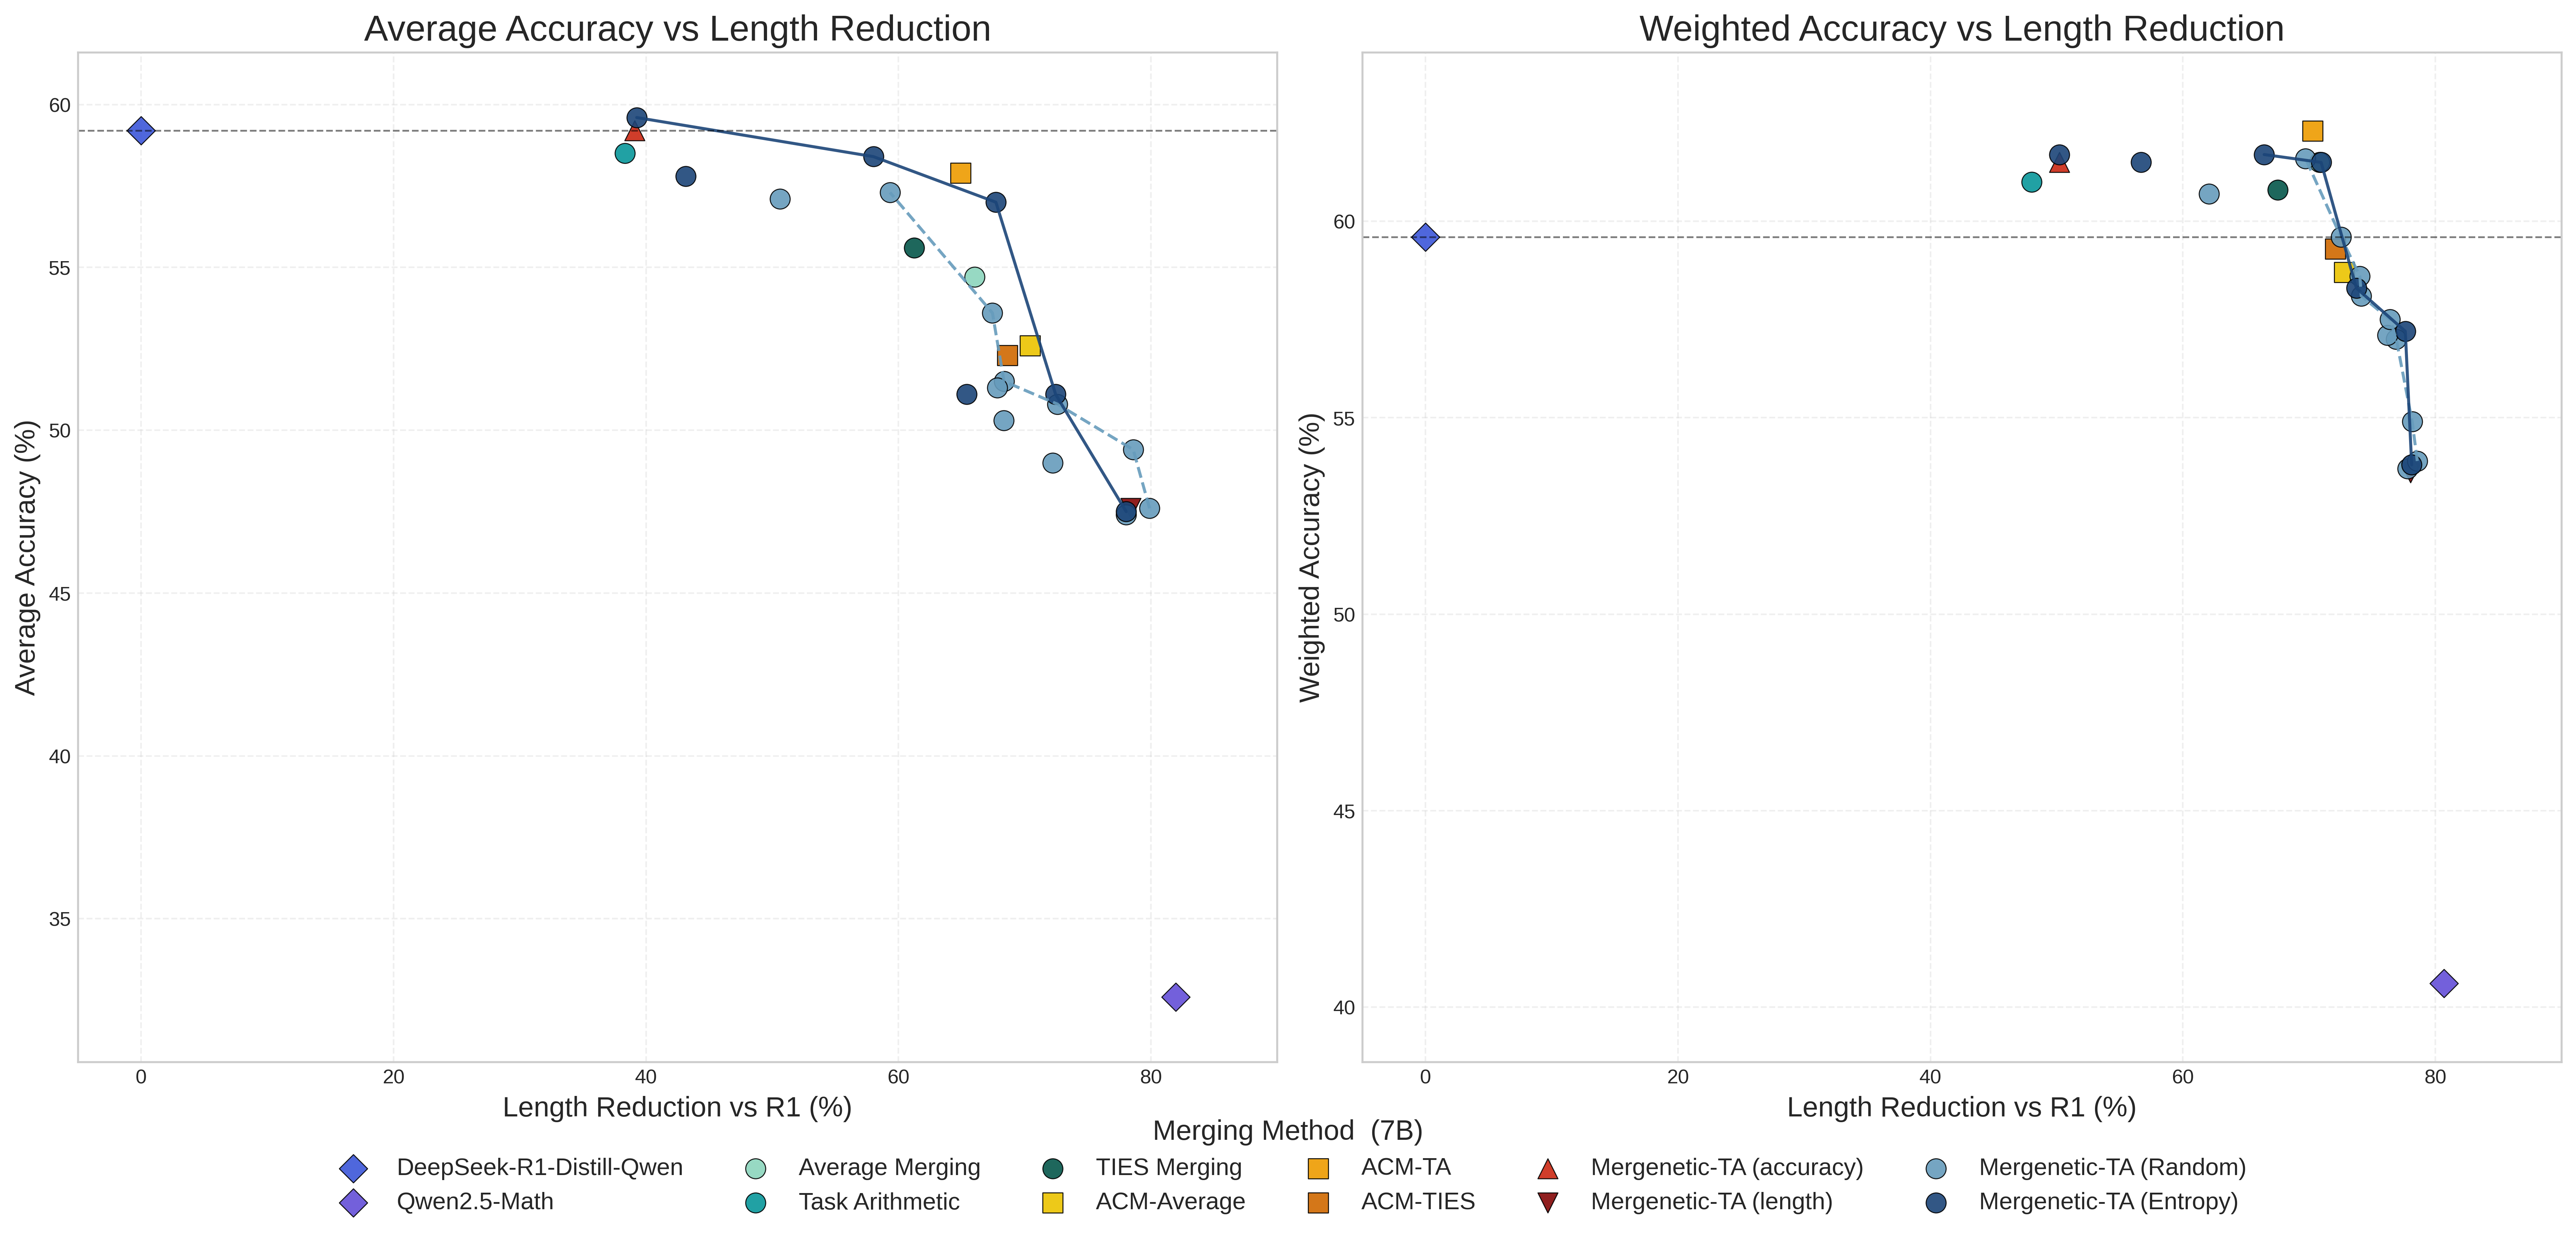

In [16]:
# === Data: 7B Models (Avg. Accuracy, Avg. Length, Family) ===
avg_models_7b = {
    "DeepSeek-R1-Distill-Qwen": (59.2, 4547.8, "DeepSeek-R1-Distill-Qwen"),
    "Qwen2.5-Math": (32.6, 820.9, "Qwen2.5-Math"), 
    
    # ACM
    "ACM-Average": (52.6, 1345.5, "ACM-Average"),   
    "ACM-TA": (57.9, 1595.2, "ACM-TA"),      
    "ACM-TIES": (52.3, 1427.1 , "ACM-TIES"), 
    
    # Baseline Merging
    "Average Merging": (54.7, 1544.2, "Average Merging"), 
    "Task Arithmetic": (58.5, 2804.3, "Task Arithmetic"), 
    "TIES Merging": (55.6, 1762.8  , "TIES Merging"), 
    
    # RANDOM
    "Mergenetic-TA Random-01": (57.1, 2246.2, "Mergenetic-TA (Random)"), # w = 0.34038545332220516
    "Mergenetic-TA Random-02": (51.5, 1439.1, "Mergenetic-TA (Random)"), # w = 0.6611344236866064
    "Mergenetic-TA Random-03": (51.3, 1463.8, "Mergenetic-TA (Random)"), # w = 0.6246144051987403
    "Mergenetic-TA Random-04": (49.4, 973.3, "Mergenetic-TA (Random)"),  # w = 0.9671220859422768
    "Mergenetic-TA Random-05": (47.4, 999.6, "Mergenetic-TA (Random)"),  # w = 0.9344015704779534
    "Mergenetic-TA Random-06": (57.3, 1849.7, "Mergenetic-TA (Random)"), # w = 0.4189519824375466
    "Mergenetic-TA Random-07": (49.0, 1263.6, "Mergenetic-TA (Random)"), # w = 0.8122458614558346
    "Mergenetic-TA Random-08": (53.6, 1480.7, "Mergenetic-TA (Random)"), # w = 0.5777720173510577
    "Mergenetic-TA Random-09": (47.6, 914.6, "Mergenetic-TA (Random)"),  # w = 0.9854345593940625
    "Mergenetic-TA Random-10": (50.8, 1246.6, "Mergenetic-TA (Random)"), # w = 0.9854345593940625
    "Mergenetic-TA Random-11": (50.3, 1439.9, "Mergenetic-TA (Random)"), # w = 0.7552632214401604
    
    # ENTROPY
    "Mergenetic-TA Entropy-01": (57.8, 2585.5, "Mergenetic-TA (Entropy)"), # w = 0.31335054703117915
    "Mergenetic-TA Entropy-02": (47.5, 998.9, "Mergenetic-TA (Entropy)"),  # w = 0.9321521177402978
    "Mergenetic-TA Entropy-03": (51.1, 1573.9, "Mergenetic-TA (Entropy)"), # w = 0.638531175783398
    "Mergenetic-TA Entropy-04": (51.1, 1253.0 , "Mergenetic-TA (Entropy)"), # w = 0.8349494944593736
    "Mergenetic-TA Entropy-05": (59.6, 2762.2, "Mergenetic-TA (Entropy)"), # w = 0.2887225431739478
    "Mergenetic-TA Entropy-06": (57.0, 1468.2, "Mergenetic-TA (Entropy)"), # w = 0.48163407295447336 
    "Mergenetic-TA Entropy-07": (58.4, 1909.5, "Mergenetic-TA (Entropy)"), # w = 0.3677109620466447
  
    # SINGLE OBJECTIVE
    "Mergenetic-TA (accuracy)": (59.2, 2769.1 , "Mergenetic-TA (accuracy)"),    # w = 0.2890858670075971
    "Mergenetic-TA (length)": (47.6, 982.2, "Mergenetic-TA (length)"),          # w = 0.9597775859528692
}

# === Weighted Averages (Weighted Accuracy, Weighted Length, Family) ===
weighted_models_7b = {
    "DeepSeek-R1-Distill-Qwen": (59.6, 3341.1, "DeepSeek-R1-Distill-Qwen"), 
    "Qwen2.5-Math": (40.6, 645.5, "Qwen2.5-Math"), 

    # ACM
    "ACM-Average": (58.7, 909.3, "ACM-Average"), 
    "ACM-TA": (62.3, 993.5, "ACM-TA"),    
    "ACM-TIES": (59.3, 932.9, "ACM-TIES"), 
    
    "Average Merging": (61.5, 975.4, "Average Merging"), 
    "Task Arithmetic": (61.0, 1736.9, "Task Arithmetic"), 
    "TIES Merging": (60.8, 1085.5, "TIES Merging"), 

    # RANDOM
    "Mergenetic-TA Random-01": (60.7, 1267.4, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-02": (58.1, 864.3, "Mergenetic-TA (Random)"), 
    "Mergenetic-TA Random-03": (58.6, 868.0, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-04": (54.9, 729.6, "Mergenetic-TA (Random)"), 
    "Mergenetic-TA Random-05": (53.7, 742.0, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-06": (61.6, 1011.9, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-07": (57.0, 771.7, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-08": (59.6, 918.0, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-09": (53.9, 716.1, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-10": (57.1, 795.2, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-11": (57.5, 788.2, "Mergenetic-TA (Random)"),
   
    # ENTROPY
    "Mergenetic-TA Entropy-01": (61.5, 1447.1, "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-02": (53.8, 730.9 , "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-03": (58.3, 877.3, "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-04": (57.2, 747.8, "Mergenetic-TA (Entropy)"), 
    "Mergenetic-TA Entropy-05": (61.7, 1663.6, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-06": (61.5, 970.6, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-07": (61.7, 1121.3, "Mergenetic-TA (Entropy)"),
    
    # SINGLE OBJECTIVE
    "Mergenetic-TA (accuracy)": (61.5, 1663.0, "Mergenetic-TA (accuracy)"), 
    "Mergenetic-TA (length)": (53.6, 734.2, "Mergenetic-TA (length)"), 
}

plot(avg_models_7b, weighted_models_7b, model_label=" (7B)", save_path="7B")

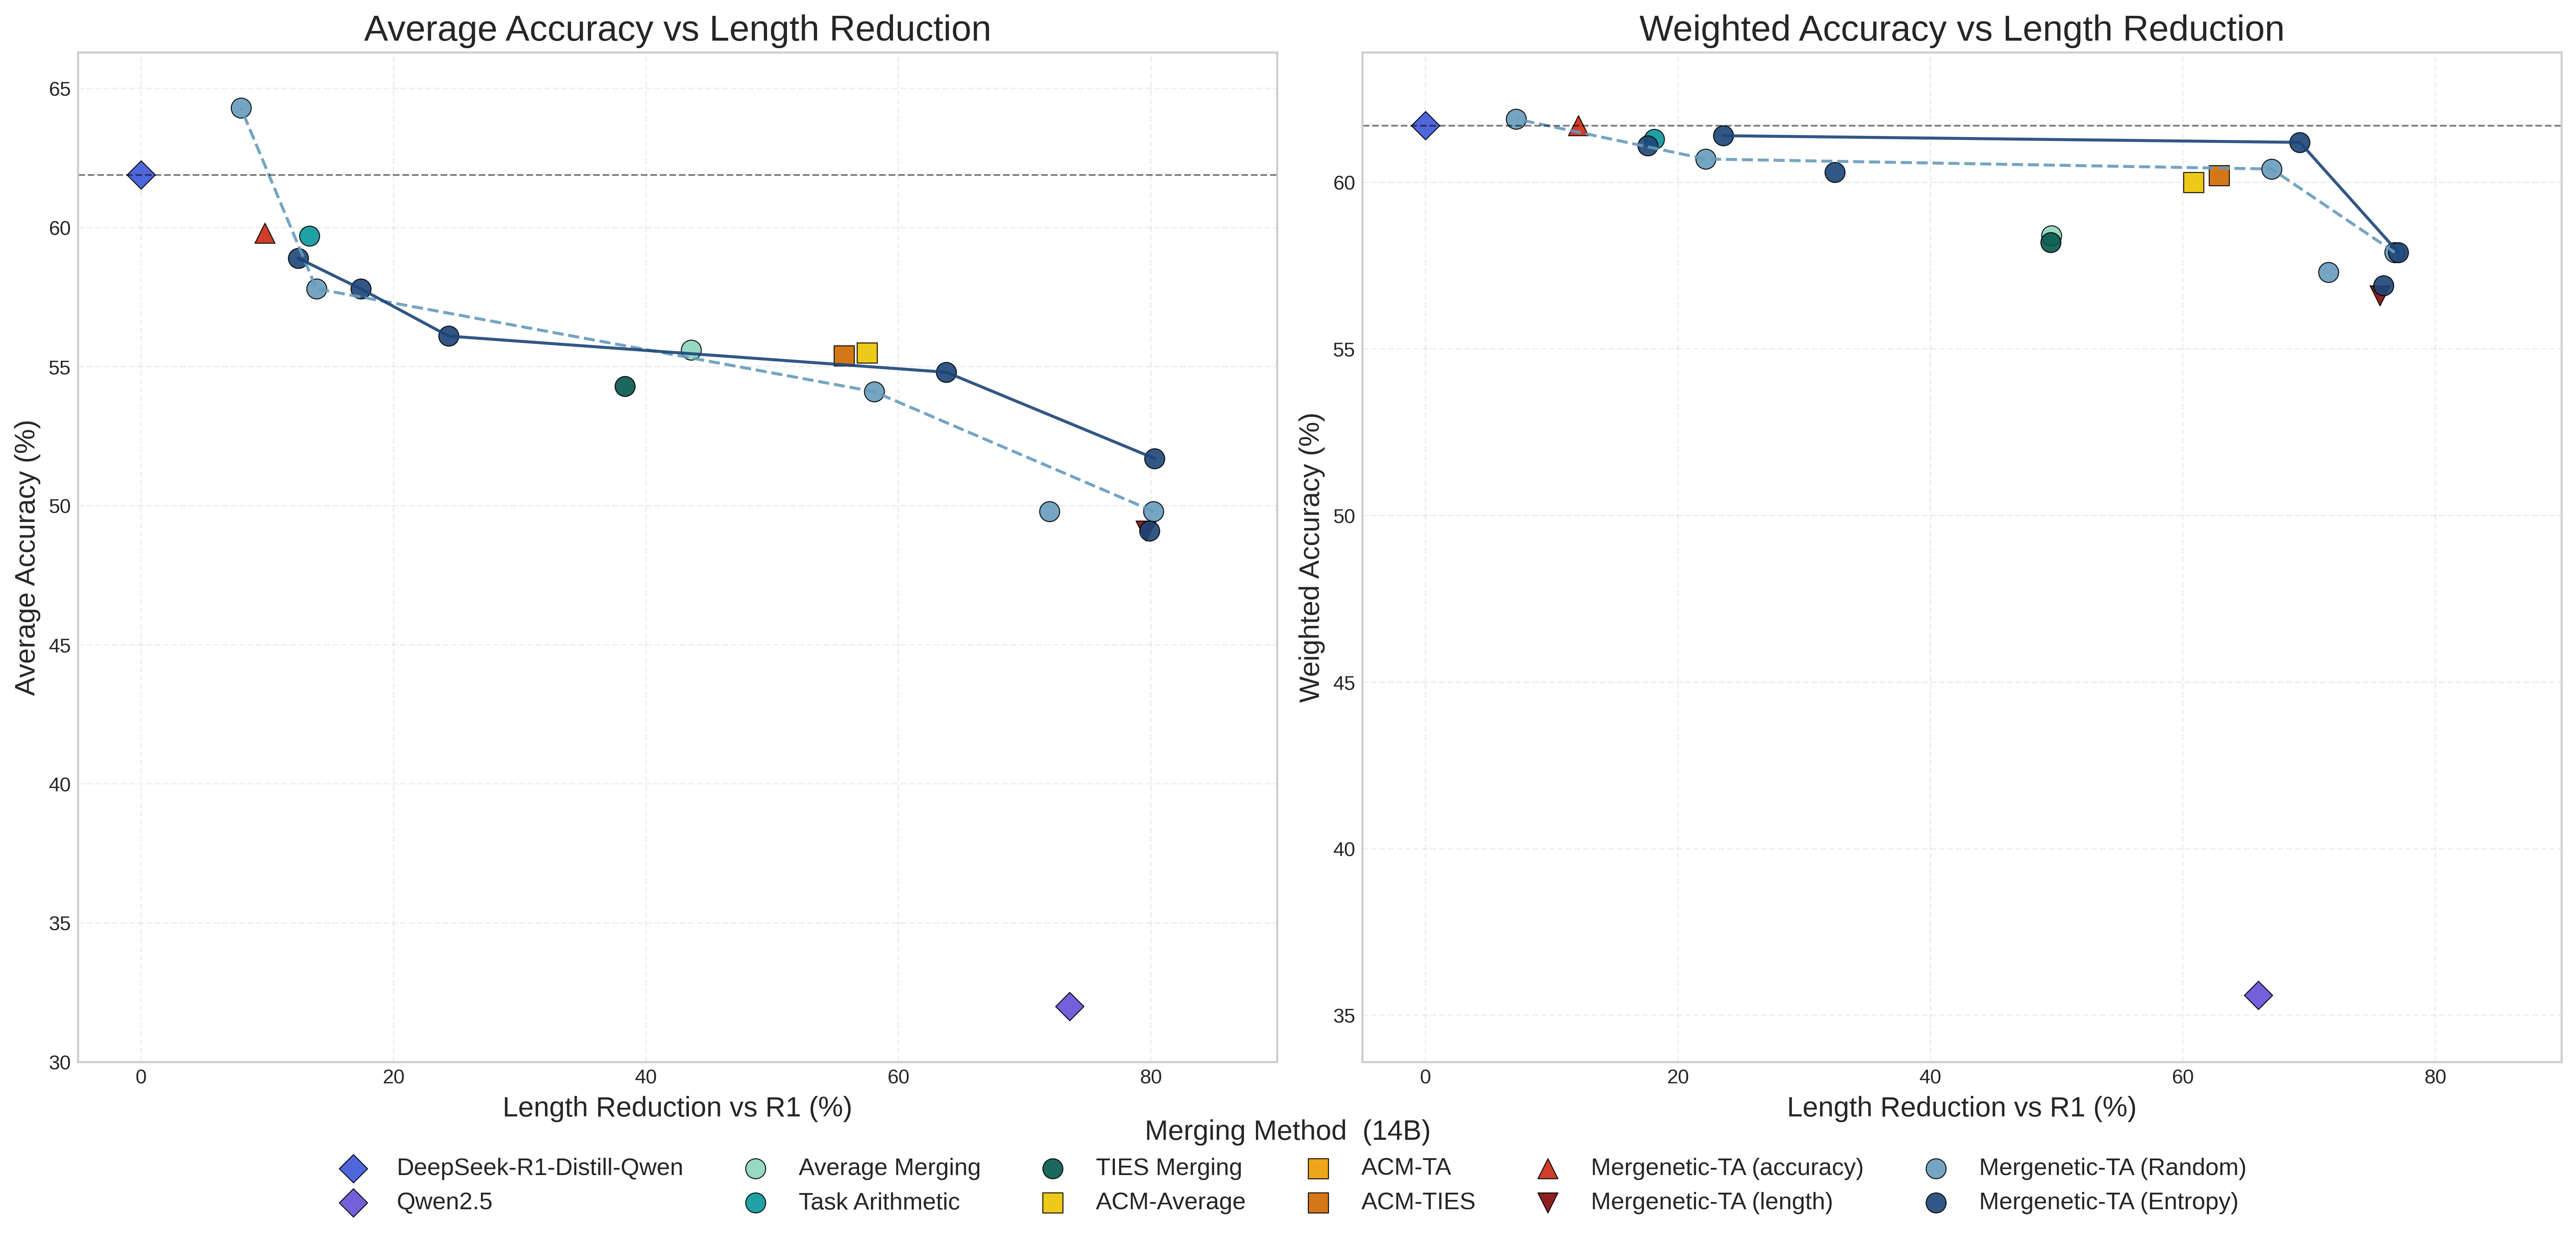

In [15]:
avg_models_14b = {
    # --- Baseline ---
    "Qwen2.5": (32.0, 1071.5, "Qwen2.5"),
    "DeepSeek-R1-Distill-Qwen": (61.9, 4050.3, "DeepSeek-R1-Distill-Qwen"),

    # --- Arithmetic merging ---       
    "Average Merging": (55.6, 2285.9 , "Average Merging"),
    "Task Arithmetic": (59.7, 3510.0, "Task Arithmetic"),
    "TIES Merging": (54.3, 2498.1, "TIES Merging"),

    # --- Activation-based merging ---
    "ACM-Average": (55.5, 1720.8, "ACM-Average"),
    "ACM-TA": (47.7, 5030.4, "ACM-TA"), 
    "ACM-TIES": (55.4, 1795.3 , "ACM-TIES"),

    # RANDOM
    "Mergenetic-TA Random-01": (54.1, 1698.3, "Mergenetic-TA (Random)"),  # w = 0.6
    "Mergenetic-TA Random-02": (49.8, 1135.4, "Mergenetic-TA (Random)"),  # w = 0.9225840794834396
    "Mergenetic-TA Random-03": (49.8, 802.1, "Mergenetic-TA (Random)"),   # w = 0.980792709486083
    "Mergenetic-TA Random-04": (57.8, 3487.6 , "Mergenetic-TA (Random)"), # w = 0.353732691166314
    "Mergenetic-TA Random-05": (64.3, 3729.8, "Mergenetic-TA (Random)"),  # w = 0.16195273573731123    
       
    # ENTROPY
    "Mergenetic-TA Entropy-01": (49.1, 814.4, "Mergenetic-TA (Entropy)"),  # w = 0.9974261469633884
    "Mergenetic-TA Entropy-02": (57.8, 3345.5, "Mergenetic-TA (Entropy)"), # w = 0.355743292103938
    "Mergenetic-TA Entropy-03": (58.9, 3546.0, "Mergenetic-TA (Entropy)"), # w = 0.3169256910294692
    "Mergenetic-TA Entropy-04": (51.7, 798.4, "Mergenetic-TA (Entropy)"),  # w = 0.975825950584803
    "Mergenetic-TA Entropy-05": (54.8, 1466.6 , "Mergenetic-TA (Entropy)"), # w = 0.644419701210226 
    "Mergenetic-TA Entropy-06": (56.1, 3063.7, "Mergenetic-TA (Entropy)"), # w = 0.41563975804415076
    
    "Mergenetic-TA (accuracy)": (59.8, 3653.4, "Mergenetic-TA (accuracy)"), # w = 0.24436215605331862
    "Mergenetic-TA (length)": (49.1, 826.8, "Mergenetic-TA (length)"),     
}

weighted_models_14b = {
    # --- Baseline ---
    "Qwen2.5": (35.6, 950.0, "Qwen2.5"),
    "DeepSeek-R1-Distill-Qwen": (61.7, 2793.0, "DeepSeek-R1-Distill-Qwen"),

    # --- Arithmetic merging ---
    "Average Merging": (58.4, 1408.1, "Average Merging"),
    "Task Arithmetic": (61.3, 2286.6, "Task Arithmetic"), 
    "TIES Merging": (58.2, 1409.5, "TIES Merging"),

    # --- Activation-based merging ---
    "ACM-Average": (60.0, 1093.3, "ACM-Average"), 
    "ACM-TA": (49.8, 3888.5, "ACM-TA"), # 48.0, 4342.7
    "ACM-TIES": (60.2, 1036.7, "ACM-TIES"),
    
    # RANDOM
    "Mergenetic-TA Random-01": (60.4, 920.8, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-02": (57.3, 794.9, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-03": (57.9, 648.6, "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-04": (60.7, 2173.3 , "Mergenetic-TA (Random)"),
    "Mergenetic-TA Random-05": (61.9, 2592.2, "Mergenetic-TA (Random)"),
    
    # ENTROPY
    "Mergenetic-TA Entropy-01": (56.9, 673.6, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-02": (61.4, 2134.2, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-03": (61.1, 2301.2, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-04": (57.9, 640.7 , "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-05": (61.2, 858.4, "Mergenetic-TA (Entropy)"),
    "Mergenetic-TA Entropy-06": (60.3, 1887.0, "Mergenetic-TA (Entropy)"),
    
    "Mergenetic-TA (accuracy)": (61.7, 2454.8, "Mergenetic-TA (accuracy)"),
    "Mergenetic-TA (length)": (56.6, 681.1, "Mergenetic-TA (length)"),
}

plot(avg_models_14b, weighted_models_14b, model_label=" (14B)", save_path="14B")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Config
CATS = ["GSM8K", "MATH500", "Minerva-Math", "OlympiadBench", "College-Math", "AIME24", "Avg", "Weighted Avg"]

PALETTE = {
    "Qwen2.5": "#9b59b6",
    "Qwen2.5-Math": "#9b59b6",
    "DeepSeek-R1-Distill-Qwen": "#3C56D9",
    "Mergenetic-TA": "#1d90ff",
    "ACM-Average": "#1abc9d", 
    "ACM-TA": "#1abc9d",
    "ACM-TIES": "#1abc9d",
}

PLOT_ORDER = [
    "Qwen2.5",
    "Qwen2.5-Math",
    "DeepSeek-R1-Distill-Qwen",
    "ACM-Average",
    "ACM-TA",
    "ACM-TIES",
    "Mergenetic-TA",
]

BASELINES = {"DeepSeek-R1-Distill-Qwen", "Qwen2.5",  "Qwen2.5-Math"}

STYLE = {
    "label": 20,
    "tick": 16,
    "title": 25,
    "legend": 20,
    "legend_title": 20,
}

# Helpers
def _radar_angles(n: int):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    return angles + angles[:1]

def _length_reduction_vs_deepseek(len_series: dict, baseline_label: str = "DeepSeek-R1"):
    """
    reduction% = 100 * (L_base - L_model) / L_base
    DeepSeek => 0% (center). Clamp to [0, 100].
    """
    if baseline_label not in len_series:
        raise KeyError(f"baseline_label='{baseline_label}' not found in len_series keys: {list(len_series.keys())}")

    base = np.array(len_series[baseline_label], dtype=float)
    if np.any(base <= 0):
        raise ValueError("Baseline lengths must be > 0 to compute reductions.")

    out = {}
    for label, vals in len_series.items():
        v = np.array(vals, dtype=float)
        if v.shape != base.shape:
            raise ValueError(
                f"Length series shape mismatch for '{label}': got {v.shape}, expected {base.shape}."
            )
        red = 100.0 * (base - v) / base
        out[label] = np.clip(red, 0.0, 100.0).tolist()
    return out


def _setup_radar_axis(
    ax,
    categories,
    title,
    rmin,
    rmax,
    major_step,
    minor_step,
    fontsize_labels=STYLE["label"],
    fontsize_ticks=STYLE["tick"],
    fontsize_title=STYLE["title"],
):
    N = len(categories)
    angles = _radar_angles(N)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=fontsize_labels)

    ax.set_ylim(rmin, rmax)

    major = np.arange(rmin, rmax + 1e-9, major_step)
    minor = np.arange(rmin, rmax + 1e-9, minor_step)

    ax.set_yticks(major)
    ax.set_yticklabels([f"{int(x)}" for x in major], fontsize=fontsize_ticks)
    ax.set_yticks(minor, minor=True)

    ax.grid(True, which="major")
    ax.grid(True, which="minor", alpha=0.3)

    ax.set_title(title, fontsize=fontsize_title, pad=20)
    return angles


def _plot_radar_series(
    ax,
    angles,
    series_dict,
    palette,
    plot_order=None,
    baselines=BASELINES,
    marker="o",
    markersize=8,
):
    keys = plot_order if plot_order is not None else list(series_dict.keys())

    for label in keys:
        if label not in series_dict:
            continue

        values = series_dict[label]
        vals = list(values) + [values[0]]

        color = palette.get(label, None)
        is_baseline = label in baselines

        linestyle = "--" if is_baseline else "-"
        line_width = 2.0 if is_baseline else 2.0
        fill_alpha = 0.25 if is_baseline else 0.25

        ax.plot(
            angles,
            vals,
            linewidth=line_width,
            linestyle=linestyle,
            label=label,
            color=color,
            marker=marker,
            markersize=markersize,
            markerfacecolor=color,
        )
        ax.fill(angles, vals, alpha=fill_alpha, color=color)

# Main plotting function
def radar_accuracy_and_length_reduction(
    scale_name,
    acc_series,
    len_series,
    palette=PALETTE,
    baseline_label="DeepSeek-R1-Distill-Qwen",
    save_path=None,
    plot_order=PLOT_ORDER,
    legend_ncol=2,
    figsize=(20, 9),
    wspace=0.25,  
    left=0.04,
    right=0.96,
    top=0.90,
    bottom=0.16,
):
    """
    1x2 plot:
      - left: accuracy radar (0..100)
      - right: length reduction vs DeepSeek (%) (0..100), DeepSeek at center (0)
    Note: we do NOT use tight_layout(), because it tends to override wspace with polar axes.
    """
    len_red = _length_reduction_vs_deepseek(len_series, baseline_label)

    fig, axes = plt.subplots(1, 2, figsize=figsize, subplot_kw={"polar": True})

    # Manual spacing (tight_layout OFF)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom, wspace=wspace)

    # --- Accuracy radar ---
    angles0 = _setup_radar_axis(
        axes[0],
        CATS,
        title="Pass@1 Accuracy (%)",
        rmin=0,
        rmax=100,
        major_step=20,
        minor_step=10,
        fontsize_labels=STYLE["label"],
        fontsize_ticks=STYLE["tick"],
        fontsize_title=STYLE["title"],
    )
    _plot_radar_series(
        axes[0],
        angles0,
        acc_series,
        palette,
        plot_order=plot_order,
    )

    # --- Length reduction radar ---
    angles1 = _setup_radar_axis(
        axes[1],
        CATS,
        title="Length Reduction vs DeepSeek-R1 (%)",
        rmin=0,
        rmax=100,
        major_step=20,
        minor_step=10,
        fontsize_labels=STYLE["label"],
        fontsize_ticks=STYLE["tick"],
        fontsize_title=STYLE["title"],
    )
    _plot_radar_series(
        axes[1],
        angles1,
        len_red,
        palette,
        plot_order=plot_order,
    )

    # --- Shared legend (bottom center) ---
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=legend_ncol,
            frameon=False,
            bbox_to_anchor=(0.5, 0),
            fontsize=STYLE["legend"],
            title=scale_name,
            title_fontsize=STYLE["legend_title"],
            handlelength=2.8,
            handletextpad=0.8,
            columnspacing=1.6,
            labelspacing=0.8,
        )

    if save_path:
        fig.savefig(save_path, dpi=750, bbox_inches="tight")

    plt.show()

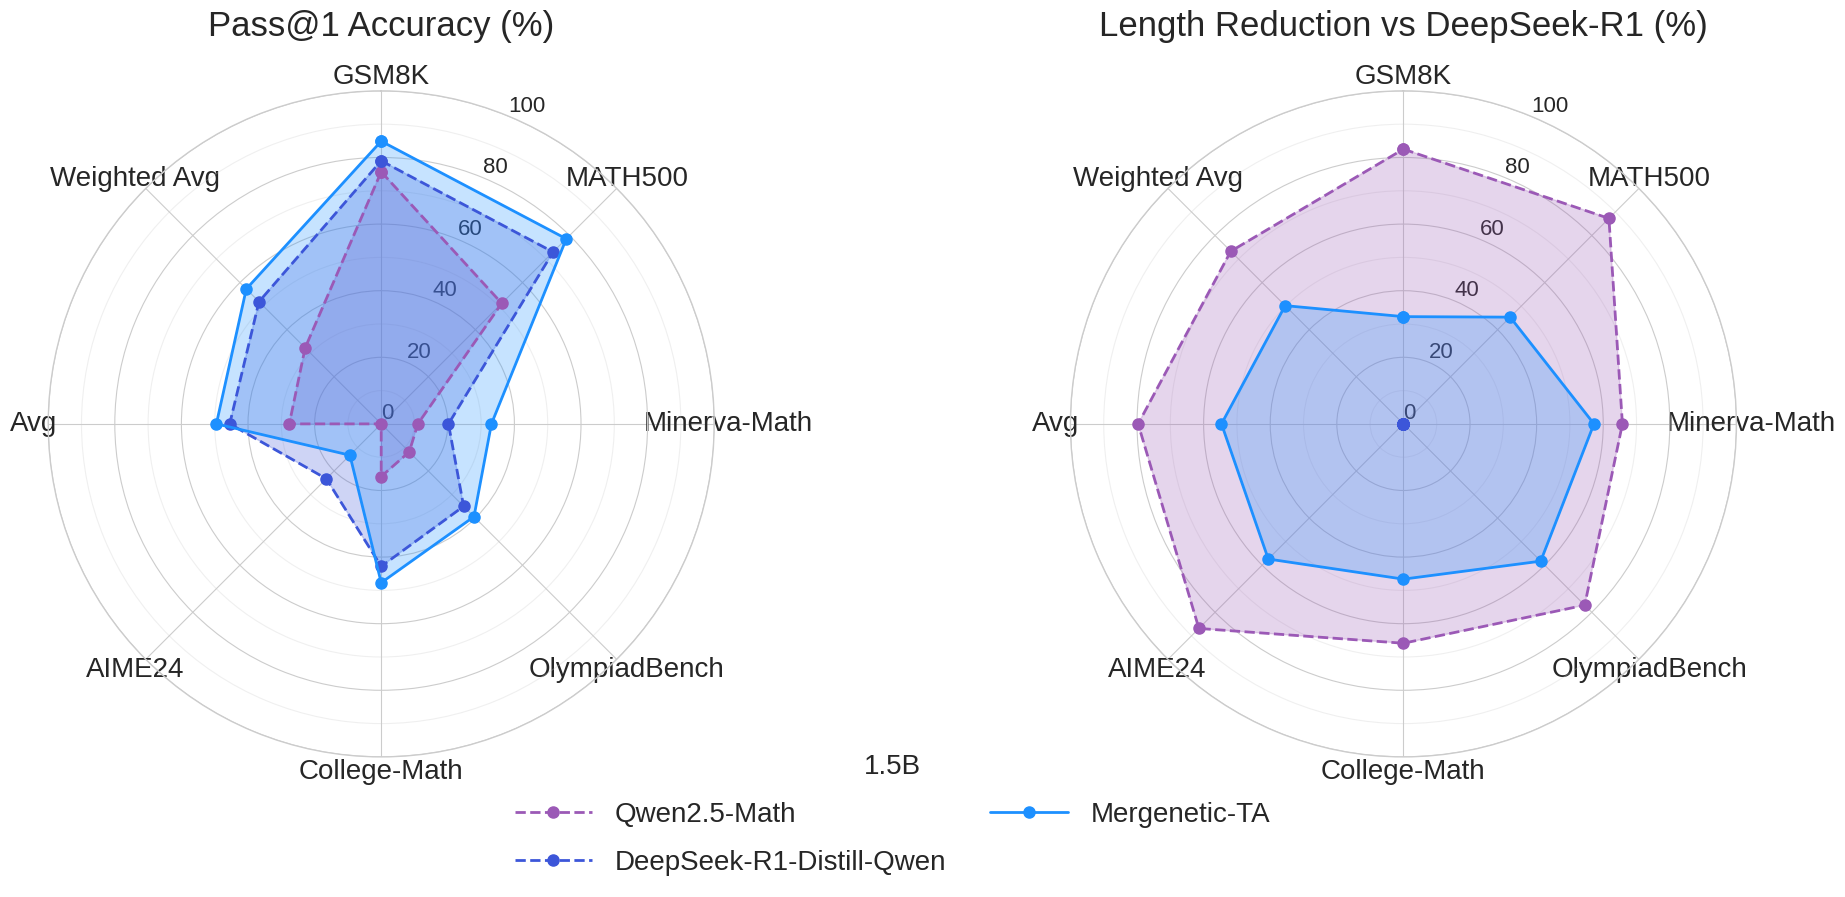

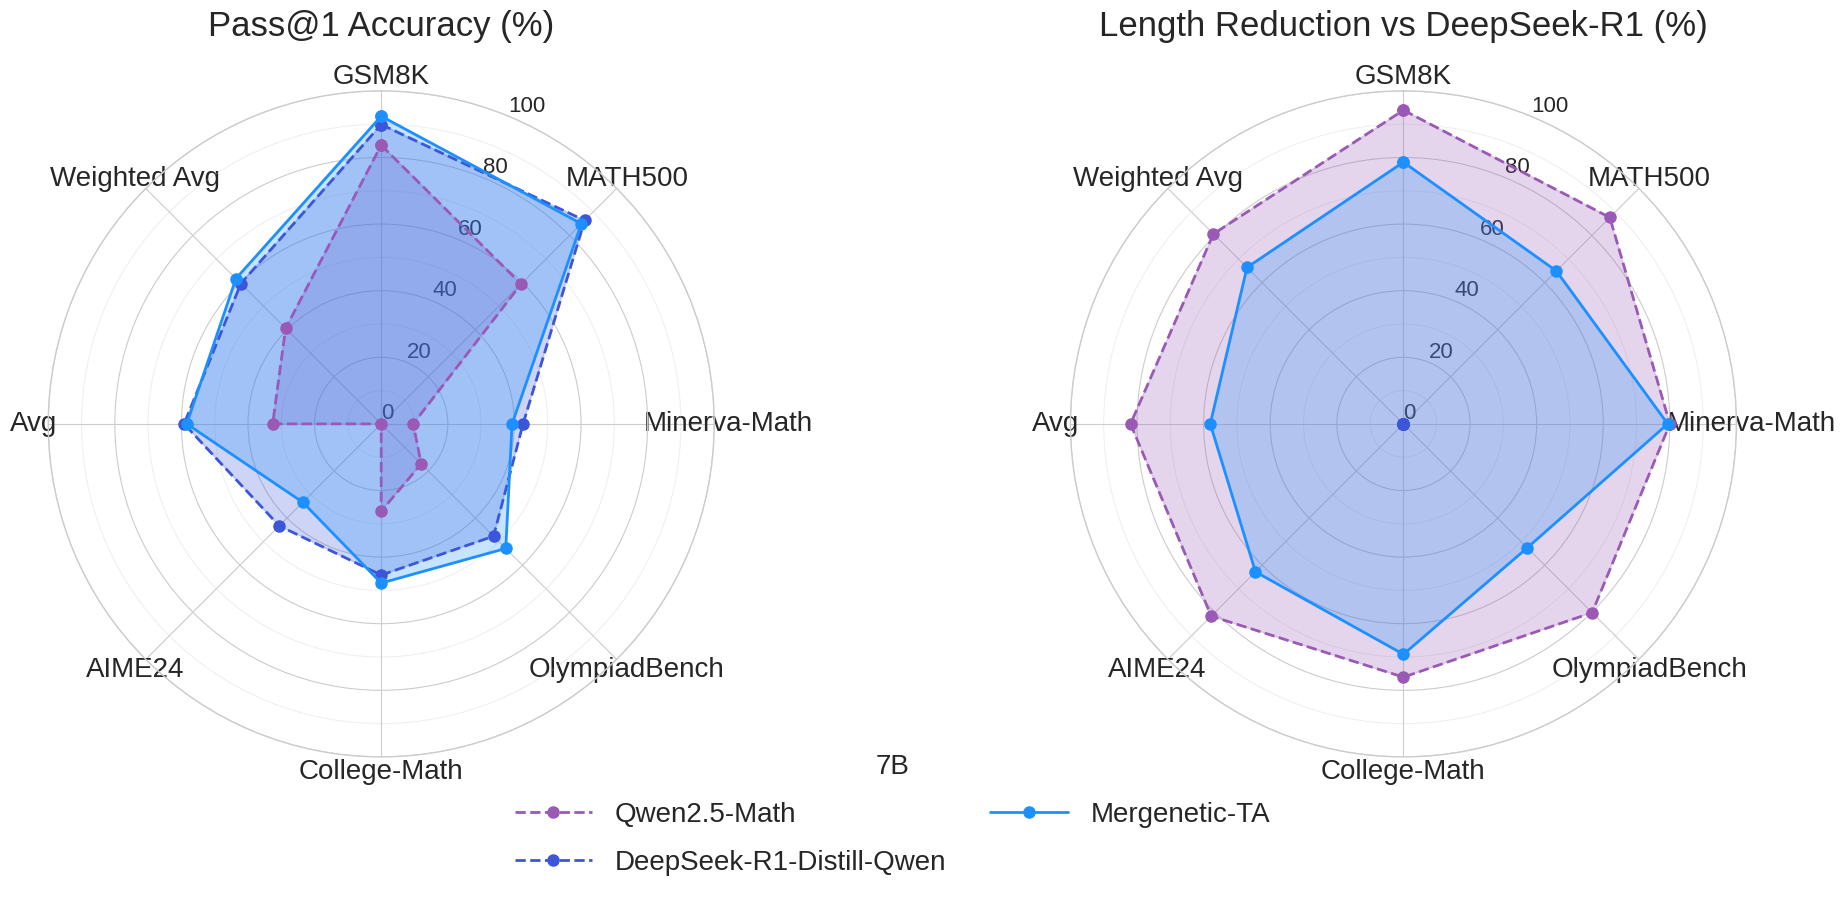

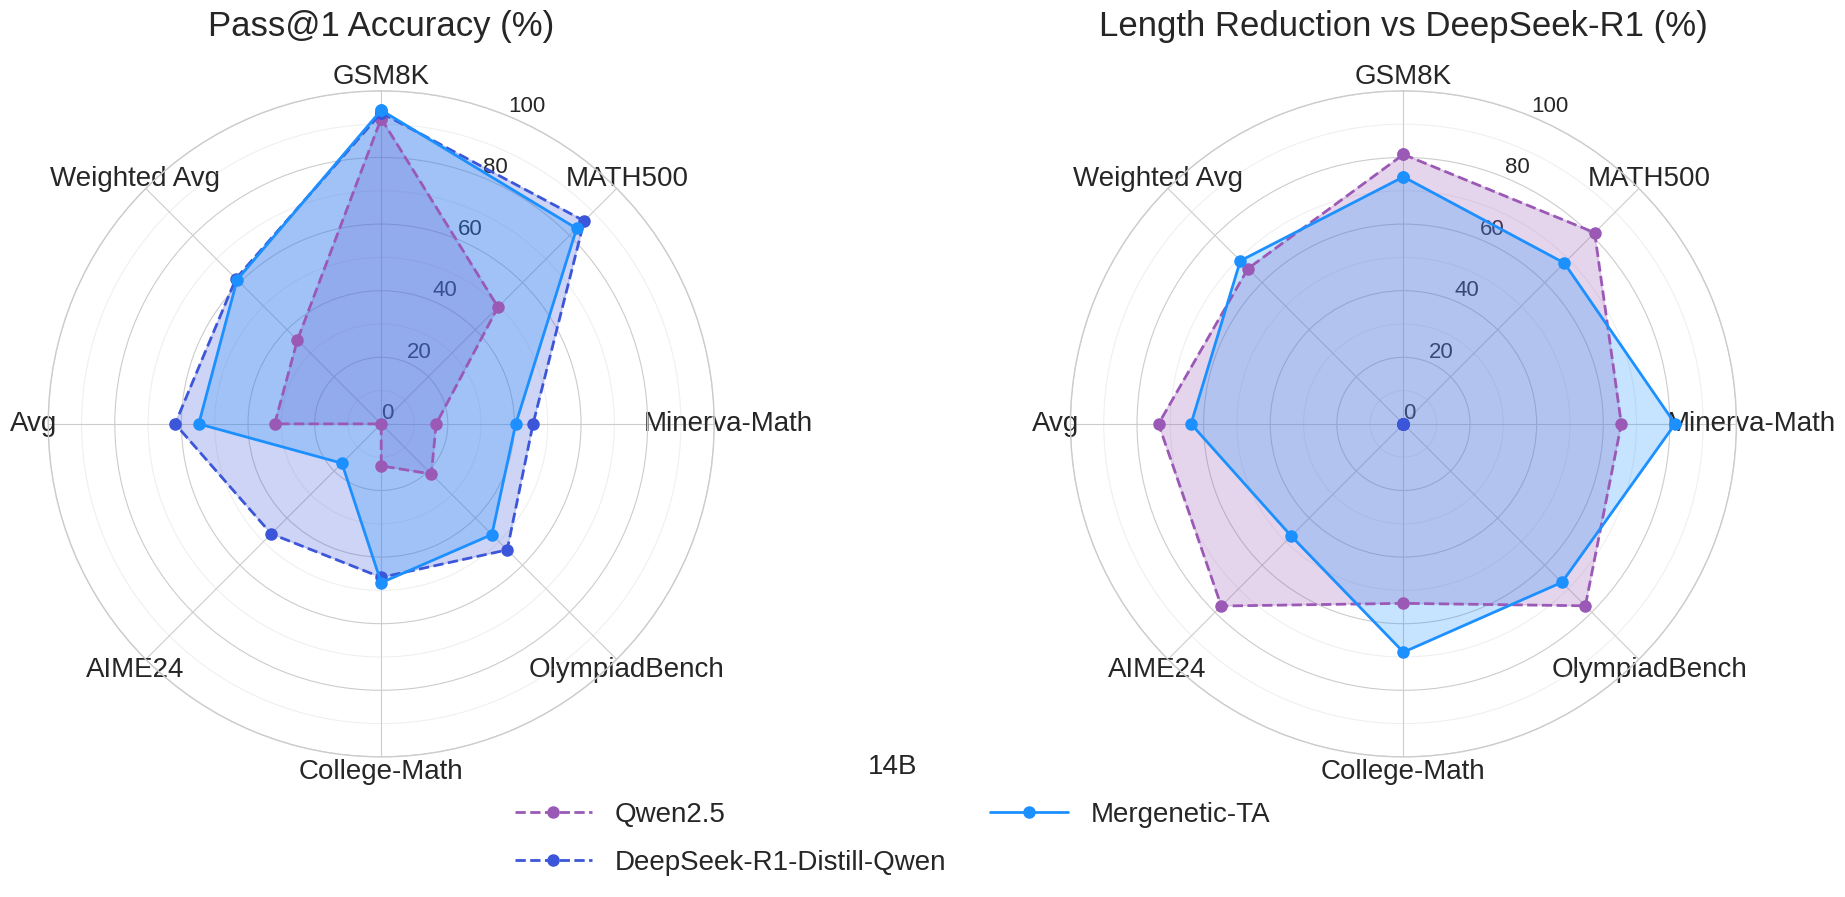

In [28]:
# DATA: 1.5B
acc_1p5b = {
    "Qwen2.5-Math": [75.7, 51.2, 11.0, 11.9, 15.8, 0.0, 27.6, 32.3],
    "DeepSeek-R1-Distill-Qwen": [79.0, 73.0, 20.2, 35.0, 42.8, 23.3, 45.5, 51.9],
    #"ACM-Average": [75.1, 69.0, 30.1, 33.5, 42.3, 3.3, 42.3, 50.8],
    #"ACM-TA": [80.2 , 73.0, 33.5, 36.3, 41.6, 13.3, 46.4, 52.6],
    #"ACM-TIES": [78.2, 69.4, 27.9, 32.7, 44.9, 13.3, 44.4, 52.4],
    "Mergenetic-TA": [84.9, 78.6, 33.1, 39.4, 47.7, 13.3, 49.5, 57.3],
}

len_1p5b = {
    "Qwen2.5-Math": [110.0, 327.2, 1032.2, 1337.7, 606.3, 1107.5, 753.5, 576.1],
    "DeepSeek-R1-Distill-Qwen": [628.7, 2570.0, 3014.8, 5814.2, 1776.6, 8432.9, 3706.2, 2158.6],
    #"ACM-Average": [503.8, 1371.6, 1027.5, 2540.7, 951.0, 4183.6, 1763.0, 1095.5],
    #"ACM-TA": [576.3, 1835.0, 1522.3, 3140.1, 1183.4, 5488.4, 2290.9, 1373.5],
    #"ACM-TIES": [469.8, 1586.0, 1263.9, 2698.9, 992.1, 4201.4, 1868.7, 1157.8],
    "Mergenetic-TA": [426.2, 1404.9, 1289.8, 2424.6, 948.3, 3593.2, 1681.2, 1074.5],
}

# DATA: 7B
acc_7b = {
    "Qwen2.5-Math": [83.7, 59.4, 9.6, 17.0, 26.2, 0.0, 32.6, 40.6],
    "DeepSeek-R1-Distill-Qwen": [89.9, 86.4, 42.6, 47.7, 45.4, 43.3, 59.2, 59.6],
    #"ACM-Average": [87.6, 81.2, 37.5, 41.8 , 47.6, 20.0, 52.6, 58.7],    
    #"ACM-TA": [92.3, 86.0, 39.7, 50.2, 49.5, 30.0, 57.9, 62.3],
    #"ACM-TIES": [86.1, 81.6, 35.7, 45.0, 48.9, 16.7, 52.3, 59.3],
    #"Mergenetic-TA": [91.4, 83.4, 40.4, 47.7, 49.2, 30.0, 57.0, 61.5], 
    "Mergenetic-TA": [92.4, 85.0, 39.3, 52.9, 47.8, 33.3, 58.4, 61.7], 
}

len_7b = {
    "Qwen2.5-Math": [104.0, 432.8, 946.8, 1228.2, 759.4, 1450.0, 820.9, 645.5],
    "DeepSeek-R1-Distill-Qwen": [1794.3, 3505.1, 4737.2, 6187.3, 3171.1, 7891.9, 4547.8, 3341.1],
    #"ACM-Average": [369.6, 1066.3, 841.7, 1981.5, 862.1, 2951.5, 1345.5 , 909.3],  
    #"ACM-TA": [354.1, 1157.2, 942.8, 2292.2, 926.5, 3898.1, 1595.2, 993.5],
    #"ACM-TIES": [378.8, 1054.7, 1020.8, 2140.1, 849.7, 3118.6, 1427.1, 932.9],
    #"Mergenetic-TA": [362.3, 1147.3, 864.3, 2433.8, 860.7, 3140.9, 1468.2, 970.6],
    "Mergenetic-TA": [384.0, 1228.6, 976.9, 2932.2, 976.9, 2932.9, 1909.5, 1121.3],
}

# DATA: 14B
acc_14b = {
    "Qwen2.5": [91.7, 49.6, 16.5, 21.3, 12.6, 0.0, 32.0, 35.6],
    "DeepSeek-R1-Distill-Qwen": [93.4, 86.2, 45.6, 53.5, 46.1, 46.7, 61.9, 61.7],
    #"ACM-Average": [90.7, 81.8, 40.8, 45.6, 47.4, 26.7, 55.5, 60.0],
    #"ACM-TA": [92.6, 69.4, 30.9, 34.8, 32.0, 26.7, 47.7, 49.8],
    #"ACM-TIES": [92.2, 81.8, 41.2, 48.0, 47.9, 26.7, 56.3, 60.9],
    "Mergenetic-TA": [94.2, 83.0, 40.4, 47.0, 47.7, 16.7, 54.8, 61.2],
}

len_14b = {
    "Qwen2.5": [202.4, 598.4, 1315.8, 1310.9, 1231.7, 1770.0, 1071.5, 950.0],
    "DeepSeek-R1-Distill-Qwen": [1061.1, 3183.6, 3806.2, 5765.1, 2671.1, 7814.4, 4050.3, 2793.0],
    #"ACM-Average": [742.2, 1337.3, 816.7, 2218.0, 937.9, 4273.0, 1720.8, 1093.3],
    #"ACM-TA": [1545.6, 4374.3, 4903.2, 7501.5, 3892.2, 7965.4, 5030.4, 3888.5],
    #"ACM-TIES": [594.3, 1284.8, 913.0, 2207.1, 911.4, 5302.0, 1868.8, 1049.5],
    "Mergenetic-TA": [273.9, 1008.8, 700.8, 1885.5, 840.0, 4090.9, 1466.6, 858.4],
}

radar_accuracy_and_length_reduction(
    "1.5B", acc_1p5b, len_1p5b,
    palette=PALETTE,
    baseline_label="DeepSeek-R1-Distill-Qwen",
    save_path="radar_1p5b_acc_len_reduction.png"
)

radar_accuracy_and_length_reduction(
    "7B", acc_7b, len_7b,
    palette=PALETTE,
    baseline_label="DeepSeek-R1-Distill-Qwen",
    save_path="radar_7b_acc_len_reduction.png"
)

radar_accuracy_and_length_reduction(
    "14B", acc_14b, len_14b,
    palette=PALETTE,
    baseline_label="DeepSeek-R1-Distill-Qwen",
    save_path="radar_14b_acc_len_reduction.png"
)

## JOBS

In [2]:
!squeue -u miacobel

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


In [ ]:
!sbatch /leonardo/home/userexternal/miacobel/project_new/mergenetic/scripts/run_mergenetic_TA.sh

In [31]:
!sbatch /leonardo/home/userexternal/miacobel/project_new/mergenetic/scripts/run_mergekit.sh

Submitted batch job 37582148


In [ ]:
!sbatch /leonardo/home/userexternal/miacobel/project_new/Qwen2.5-Math/evaluation/scripts/l2s_eval.sh

Submitted batch job 37581948
